# **SISTEMAS DE  VISION 317**
# **PRÁCTICA #8: PIA (Juego de TIC TAC TOE (Gato)).**
**Jose Antonio Martinez Calan 2127803**

=== TIC TAC TOE INTERACTIVO ===
Numeración del tablero:
 0 | 1 | 2 
-----------
 3 | 4 | 5 
-----------
 6 | 7 | 8 

Para jugar, ejecuta: jugar(movimiento)
Ejemplo: jugar(4)  para poner en el centro
Movimientos disponibles: [0, 1, 2, 3, 4, 5, 6, 7, 8]


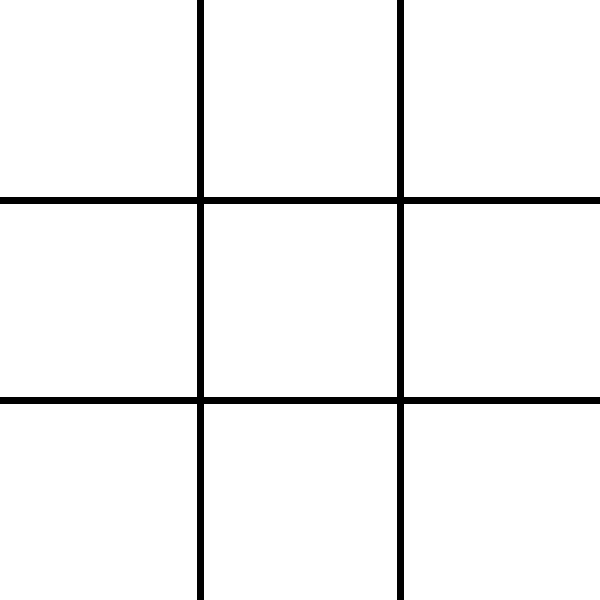

Instrucciones:
Usa jugar(0) a jugar(8) para hacer movimientos
Usa reiniciar() para empezar de nuevo
Movimientos disponibles: [0, 1, 2, 3, 4, 5, 6, 7, 8]


In [3]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import IPython.display as display
from IPython.display import clear_output

class TicTacToeColab:
    def __init__(self):
        self.board = [" "] * 9
        self.current_player = "X"
        self.game_over = False
        self.create_board()

        self.win_combos = [
            [0, 1, 2], [3, 4, 5], [6, 7, 8],
            [0, 3, 6], [1, 4, 7], [2, 5, 8],
            [0, 4, 8], [2, 4, 6]
        ]

    def create_board(self):
        self.board_img = np.ones((600, 600, 3), dtype=np.uint8) * 255
        cv2.line(self.board_img, (200, 0), (200, 600), (0, 0, 0), 5)
        cv2.line(self.board_img, (400, 0), (400, 600), (0, 0, 0), 5)
        cv2.line(self.board_img, (0, 200), (600, 200), (0, 0, 0), 5)
        cv2.line(self.board_img, (0, 400), (600, 400), (0, 0, 0), 5)

    def check_winner(self, player):
        for combo in self.win_combos:
            if (self.board[combo[0]] == player and
                self.board[combo[1]] == player and
                self.board[combo[2]] == player):
                return True
        return False

    def draw_move(self, cell, player):
        row = cell // 3
        col = cell % 3
        x1, y1 = col * 200, row * 200
        x2, y2 = x1 + 200, y1 + 200

        if player == "X":
            cv2.line(self.board_img, (x1 + 20, y1 + 20), (x2 - 20, y2 - 20), (255, 0, 0), 8)
            cv2.line(self.board_img, (x2 - 20, y1 + 20), (x1 + 20, y2 - 20), (255, 0, 0), 8)
        else:
            cv2.circle(self.board_img, (x1 + 100, y1 + 100), 80, (0, 0, 255), 8)

    def make_move(self, cell):
        if self.game_over:
            return False, "El juego ya terminó"
        if self.board[cell] != " ":
            return False, "Esa celda ya está ocupada"

        self.board[cell] = self.current_player
        self.draw_move(cell, self.current_player)

        if self.check_winner(self.current_player):
            self.game_over = True
            return True, f"¡Jugador {self.current_player} ha ganado!"
        elif " " not in self.board:
            self.game_over = True
            return True, "¡Empate!"
        else:
            self.current_player = "O" if self.current_player == "X" else "X"
            return True, f"Turno del jugador {self.current_player}"

    def display_board(self):
        rgb_board = cv2.cvtColor(self.board_img, cv2.COLOR_BGR2RGB)
        cv2_imshow(rgb_board)

    def reset_game(self):
        self.board = [" "] * 9
        self.current_player = "X"
        self.game_over = False
        self.create_board()

    def get_available_moves(self):
        return [i for i, cell in enumerate(self.board) if cell == " "]

# Crear juego
game = TicTacToeColab()

print("=== TIC TAC TOE INTERACTIVO ===")
print("Numeración del tablero:")
print(" 0 | 1 | 2 ")
print("-----------")
print(" 3 | 4 | 5 ")
print("-----------")
print(" 6 | 7 | 8 ")
print("\nPara jugar, ejecuta: jugar(movimiento)")
print("Ejemplo: jugar(4)  para poner en el centro")
print("Movimientos disponibles:", game.get_available_moves())

def jugar(movimiento):
    global game

    if game.game_over:
        print("El juego ya terminado. Ejecuta reiniciar() para jugar otra vez.")
        return

    success, message = game.make_move(movimiento)
    print(message)

    clear_output(wait=True)
    game.display_board()

    print(f"Movimiento realizado en posición: {movimiento}")
    print(f"Jugador actual: {game.current_player}")
    print("Movimientos disponibles:", game.get_available_moves())

    if game.game_over:
        print("\n¡JUEGO TERMINADO!")
        print("Ejecuta reiniciar() para jugar otra vez")

def reiniciar():
    global game
    game = TicTacToeColab()
    clear_output(wait=True)
    print("=== JUEGO REINICIADO ===")
    game.display_board()
    print("Numeración del tablero:")
    print(" 0 | 1 | 2 ")
    print("-----------")
    print(" 3 | 4 | 5 ")
    print("-----------")
    print(" 6 | 7 | 8 ")
    print("\nMovimientos disponibles:", game.get_available_moves())
    print("Para jugar usa: jugar(movimiento)")

# Mostrar tablero inicial
game.display_board()
print("Instrucciones:")
print("Usa jugar(0) a jugar(8) para hacer movimientos")
print("Usa reiniciar() para empezar de nuevo")
print("Movimientos disponibles:", game.get_available_moves())